In [3]:
# Testing objective function output

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
eq_init = desc.io.load("equil_Helios_E0090-13_DESC_fixed.h5")
obj = TrappedResonance(eq_init,KE_frac=np.array([0.01]),rho=np.linspace(0.1,0.9,15),num_pitch=1,alpha=np.linspace(0,2*np.pi,10))
# grid is set in init of TrappedResonance class
obj.build()
value = obj.compute(eq_init.params_dict) # when not flattened, this shape is (rho,pitch,energy)
# value = eq_init.compute('f_tr',grid=grid)

print(value)
# print(np.shape(value['alpha_drift_avg']))


Precomputing transforms
[[[   0.        ]]

 [[   0.        ]]

 [[   0.        ]]

 [[   0.        ]]

 [[   0.        ]]

 [[   0.        ]]

 [[   0.        ]]

 [[   0.        ]]

 [[ 177.69888704]]

 [[ 212.76188209]]

 [[ 113.26063538]]

 [[  54.00778463]]

 [[ 441.52181294]]

 [[4092.64538666]]

 [[7172.23055233]]]


In [4]:
value.shape # (rho, pitch, energy)

(15, 1, 1)

In [ ]:
# debug cell (restart kernel and run before running optimizer)
import sys
import os
import math

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../../"))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 20

import desc.io
from desc.grid import LinearGrid, ConcentricGrid
from desc.objectives import (
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    AspectRatio,
    ForceBalance,
    QuasisymmetryBoozer,
    QuasisymmetryTwoTerm,
    QuasisymmetryTripleProduct,
    ObjectiveFromUser,
    GammaC,
    TrappedResonance
)
from desc.optimize import Optimizer
from desc.plotting import (
    plot_grid,
    plot_boozer_modes,
    plot_boozer_surface,
    plot_qs_error,
    plot_boundaries,
    plot_boundary,
)
# load initial equilibrium
# eq_init = desc.io.load("qs_initial_guess.h5") # QI
eq_init = desc.io.load("desc_eq_new_QH_aScaling.h5") # QH

# Specify equilibrium nfp and helicity
# N = -1 # QH helicity
# N = 0 # QA
nfp = eq_init.NFP
s_input = np.linspace(0.1,0.9,3) # surfaces to test, rho = sqrt(s) is calculated below. DESC 

# optimizer = Optimizer("proximal-scipy-bfgs")
optimizer = Optimizer("proximal-lsq-exact")

# indices of boundary modes we want to optimize
idx_Rcc = eq_init.surface.R_basis.get_idx(M=1, N=2)
idx_Rss = eq_init.surface.R_basis.get_idx(M=-1, N=-2)
idx_Zsc = eq_init.surface.Z_basis.get_idx(M=-1, N=2)
idx_Zcs = eq_init.surface.Z_basis.get_idx(M=1, N=-2)
print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_init.surface.R_basis.modes[0:10])

# boundary modes to constrain
R_modes = np.delete(eq_init.surface.R_basis.modes, [idx_Rcc, idx_Rss], axis=0)
Z_modes = np.delete(eq_init.surface.Z_basis.modes, [idx_Zsc, idx_Zcs], axis=0)

eq_qs_T = eq_init.copy()  # make a copy of the original one
# constraints
constraints = (
    ForceBalance(eq=eq_qs_T),  # enforce JxB-grad(p)=0 during optimization
    FixBoundaryR(eq=eq_qs_T, modes=R_modes),  # fix specified R boundary modes
    FixBoundaryZ(eq=eq_qs_T, modes=Z_modes),  # fix specified Z boundary modes
    FixPressure(eq=eq_qs_T),  # fix pressure profile
    FixIota(eq=eq_qs_T),  # fix rotational transform profile
    FixPsi(eq=eq_qs_T),  # fix total toroidal magnetic flux
)

# Create a grid in (rho, theta, zeta) coordinates
# rho = np.linspace(0.1,0.9,5)
rho=abs(np.sqrt(s_input))
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq_init._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0, 12 * np.pi, 300), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
# grid has the number of nodes equal to len(rho)*len(alpha)*length(zeta)

# Grid for QuasisymmetryTripleProduct objective
grid_vol = ConcentricGrid(
    L=eq_init.L_grid,
    M=eq_init.M_grid,
    N=eq_init.N_grid,
    NFP=eq_init.NFP,
    sym=eq_init.sym,
)

# Objective for resonance
objective_fT = ObjectiveFunction(
    (
        QuasisymmetryTripleProduct(eq=eq_qs_T, grid=grid_vol),
        TrappedResonance(eq=eq_qs_T, grid=grid)
    ), 
)

In [ ]:
eq_qs_T, result_T = eq_qs_T.optimize(
    objective=objective_fT,
    constraints=constraints,
    optimizer=optimizer,
    ftol=5e-2,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    maxiter=10,  # maximum number of iterations
    options={
        "perturb_options": {"order": 2, "verbose": 0},  # use 2nd-order perturbations
        "solve_options": {
            "ftol": 5e-3,
            "xtol": 1e-6,
            "gtol": 1e-6,
            "verbose": 0,
        },  # for equilibrium subproblem
    },
    copy=False,  # copy=False we will overwrite the eq_qs_T object with the optimized result
    verbose=3,
)

TESTING THE DESC TUTORIAL "DESC_TrappedRes/docs/notebooks/tutorials/basic_optimization.ipynb"

In [ ]:
# Copy the basic_optimization.ipynb code here

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 20

import desc.io
from desc.grid import LinearGrid, ConcentricGrid
from desc.objectives import (
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    AspectRatio,
    ForceBalance,
    QuasisymmetryBoozer,
    QuasisymmetryTwoTerm,
    QuasisymmetryTripleProduct,
)
from desc.optimize import Optimizer
from desc.plotting import (
    plot_grid,
    plot_boozer_modes,
    plot_boozer_surface,
    plot_qs_error,
    plot_boundaries,
    plot_boundary,
)

# load initial equilibrium
eq_init = desc.io.load("qs_initial_guess.h5")

optimizer = Optimizer("proximal-lsq-exact")

# indices of boundary modes we want to optimize
idx_Rcc = eq_init.surface.R_basis.get_idx(M=1, N=2)
idx_Rss = eq_init.surface.R_basis.get_idx(M=-1, N=-2)
idx_Zsc = eq_init.surface.Z_basis.get_idx(M=-1, N=2)
idx_Zcs = eq_init.surface.Z_basis.get_idx(M=1, N=-2)
print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_init.surface.R_basis.modes[0:10])

# boundary modes to constrain
R_modes = np.delete(eq_init.surface.R_basis.modes, [idx_Rcc, idx_Rss], axis=0)
Z_modes = np.delete(eq_init.surface.Z_basis.modes, [idx_Zsc, idx_Zcs], axis=0)

eq_qs_T = eq_init.copy()  # make a copy of the original one
# constraints
constraints = (
    ForceBalance(eq=eq_qs_T),  # enforce JxB-grad(p)=0 during optimization
    FixBoundaryR(eq=eq_qs_T, modes=R_modes),  # fix specified R boundary modes
    FixBoundaryZ(eq=eq_qs_T, modes=Z_modes),  # fix specified Z boundary modes
    FixPressure(eq=eq_qs_T),  # fix pressure profile
    FixIota(eq=eq_qs_T),  # fix rotational transform profile
    FixPsi(eq=eq_qs_T),  # fix total toroidal magnetic flux
)

# objective
grid_vol = ConcentricGrid(
    L=eq_init.L_grid,
    M=eq_init.M_grid,
    N=eq_init.N_grid,
    NFP=eq_init.NFP,
    sym=eq_init.sym,
)
plot_grid(grid_vol, figsize=(8, 8))

objective_fT = ObjectiveFunction(QuasisymmetryTripleProduct(eq=eq_qs_T, grid=grid_vol))

eq_qs_T, result_T = eq_qs_T.optimize(
    objective=objective_fT,
    constraints=constraints,
    optimizer=optimizer,
    ftol=5e-2,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    maxiter=50,  # maximum number of iterations
    options={
        "perturb_options": {"order": 2, "verbose": 0},  # use 2nd-order perturbations
        "solve_options": {
            "ftol": 5e-3,
            "xtol": 1e-6,
            "gtol": 1e-6,
            "verbose": 0,
        },  # for equilibrium subproblem
    },
    copy=False,  # copy=False we will overwrite the eq_qs_T object with the optimized result
    verbose=3,
)

TESTING THE OBJECTIVE FUNCTION VALUE

$ y = \omega_{\zeta} - \omega_{\zeta}^r $

If $|y|<0.5$, this is run:
$
f_{ijr} = A e^{-w ( (y+0.5)^2 + (y+0.5) )^t}
$
Otherwise, 
$
f_{ijr} = 0
$

$ f_{ij} = \sum_{r=1}^{N_r} (f_{ijr}) $, $N_r = $ number of resonances considered.

In [2]:
# With two pitch inverses and three surfaces considered. Use desc_eq_new_QH_aScaling.h5
import numpy as np
# omega_arr = np.array([[-1.35078567e-04, -2.88730399e-05],[-1.21966454e-05, -2.42665365e-06],[-5.19323354e-06, -1.03486556e-06]]) # omegas outputted from first cell in this document (just runnning the objective function)
# omega_arr = np.array([[0.2,0.4,0.9],[-1.4,-0.1,0.01]])
omega_arr = np.array([
    [-1.35078567e-04, -2.88730399e-05],
    [-1.21966454e-05, -2.42665365e-06],
    [-5.19323354e-06, -1.03486556e-06]
    ])

res_arr = np.array([ 0.,          1. ,        -1. ,         0.5   ,     -0.5     ,    2.,
 -2.     ,     3.14159265,  3.14159265]) # resonances outputted from first cell in this document (just runnning the objective function)

In [ ]:
import numpy as np
# Calculate objective function (per surface per pitch angle)
res_broad = res_arr[None,None,:] # make 3D array with res values on axis=2
res_broad = np.broadcast_to(res_broad, (omega_arr.shape[0], omega_arr.shape[1], res_arr.shape[0]))
omega_broad = np.broadcast_to(omega_arr[...,None], (omega_arr.shape[0],omega_arr.shape[1],res_arr.shape[0]))


# [:,:,0] is for all the omegas
# [0,0,:] is for all the resonances
y = omega_broad - res_broad
# print(y[:,:,0])
domega = 0.5 # this value must stay at 0.5 or else the entire function must be modified
condition = np.logical_and(abs(y) < domega, res_broad!=np.pi) # check that corresponding omega value is less than 0.5 away from the resonance and not jnp.pi (unset)
# Set weights
w = 1
t = -1
A = np.ones((np.shape(omega_broad))) * 100 # can set to vary with order of resonance if desired


# fp = np.clip(-500,-w * (( -((y+0.5)**2) + (y+0.5) )**t),500)
# print(omega_broad[0,0,:])
# print(res_broad[0,0,:])
# print(fp[0,0,:])


obj_out1 = np.where(
    condition,
    A * np.exp( np.clip(-w * (( -((y+0.5)**2) + (y+0.5) )**t),-500,500) ),
    0
    ) # need to broadcast res_arr to 3D to match each res with each 2D matrix of omega_arr and then do this subtraction and jnp.where operation

obj_out = np.sum(obj_out1,axis=2) # outputs array with size (rho,pitch)
# # print(res_broad[:,:,0])
num_pitch=2
num_rho = 3
obj_out = np.reshape(obj_out,num_pitch*num_rho)
print(obj_out)

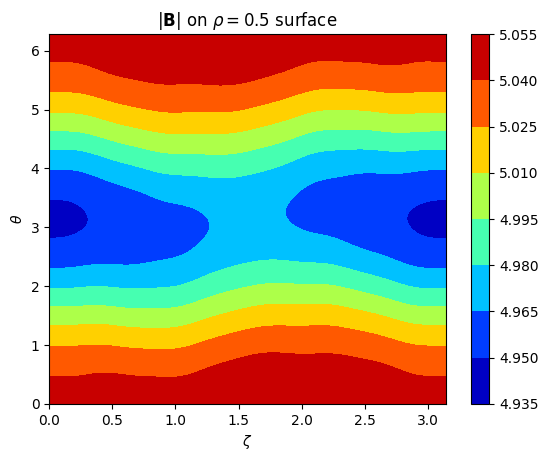

In [5]:
# Equilibrium Examination

from desc.equilibrium import Equilibrium
from desc.grid import LinearGrid
import matplotlib.pyplot as plt
eq = Equilibrium.load("equil_Helios_E0090-13_DESC_fixed.h5")

grid_1 = LinearGrid(rho=np.array(0.1), M=50, N=50, NFP=eq.NFP, endpoint=True)
mod_B_data = eq.compute("|B|", grid=grid_1)
mod_B = mod_B_data["|B|"] # need to shape into 2D array to plot
zeta = (
    grid_1.nodes[:, 2]
    .reshape((grid_1.num_theta, grid_1.num_rho, grid_1.num_zeta), order="F")
    .squeeze()
)
theta = (
    grid_1.nodes[:, 1]
    .reshape((grid_1.num_theta, grid_1.num_rho, grid_1.num_zeta), order="F")
    .squeeze()
)
mod_B = mod_B.reshape(
    (grid_1.num_theta, grid_1.num_rho, grid_1.num_zeta), order="F"
)
# plot contours of |B| on the rho=0.5 surface
plt.figure()
plt.contourf(zeta, theta, mod_B[:, 0, :], cmap="jet")
plt.xlabel(r"$\zeta$")
plt.ylabel(r"$\theta$")
plt.title(r"$|\mathbf{B}|$ on $\rho=0.5$ surface")
plt.colorbar();
plt.savefig("modB_rho05.png")
#plt.show()



In [26]:
# Equilibrium output
from desc.equilibrium import Equilibrium
from desc.vmec import VMECIO
eq = Equilibrium.load('equil_Helios_E0090-13_DESC_fixed.h5')

VMECIO.save(eq=eq,path="/Users/paullab/codes/kinetic_poincare/trapped_map/wout_equil_Helios_E0090-13_DESC_fixed.nc")
# VMECIO.write_vmec_input(eq=eq,fname='test')

Computing data
Saving parameters
Saving R
Saving Z
Saving lambda
Saving Jacobian
Saving |B|
Saving B^theta
Saving B^zeta
Saving B_psi
Saving B_theta
Saving B_zeta
Saving J^theta*sqrt(g)
Saving J^zeta*sqrt(g)
